# Distance Threshold Exceedance Analysis

## Proportion of SALs Beyond Pharmacy Access Thresholds (k = 1, 2, 3)

**Tess Vu**

Binary accessibility screening: for each SAL, does a pharmacy exist
within a given network distance threshold? This complements the 2SFCA by
providing a policy-legible metric that avoids decay functions,
demand-weighting, and provincial quantiles. The question is simple:
**can people physically reach medication or not?**

Three levels of k are analyzed separately:

- **k = 1 (reachability):** Can a person reach *any* pharmacy within the
  threshold? This is the minimum viability question.
- **k = 2 (redundancy):** Is there a second pharmacy within reach? If
  the nearest pharmacy is closed, stocked out, or overcrowded, is there
  a fallback?
- **k = 3 (choice):** Do residents have meaningful options? Three
  reachable pharmacies suggests a functioning local market rather than a
  single point of dependency.

Thresholds are applied to pre-computed k-nearest-pharmacy distances
(Euclidean, pedestrian network, drive network) from SAL centroids,
produced by the `sal_pharmacy_distance_k3` notebook.

## SETUP AND IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [18]:
# Register Space Mono fonts.
for f in [
    "data/Space_Mono/SpaceMono-Regular.ttf",
    "data/Space_Mono/SpaceMono-Bold.ttf",
    "data/Space_Mono/SpaceMono-Italic.ttf",
    "data/Space_Mono/SpaceMono-BoldItalic.ttf",
]:
    fm.fontManager.addfont(f)

# Register Space Grotesk fonts.
for f in [
    "data/Space_Grotesk/static/SpaceGrotesk-Regular.ttf",
    "data/Space_Grotesk/static/SpaceGrotesk-Medium.ttf",
    "data/Space_Grotesk/static/SpaceGrotesk-Bold.ttf",
    "data/Space_Grotesk/static/SpaceGrotesk-Light.ttf",
    "data/Space_Grotesk/static/SpaceGrotesk-SemiBold.ttf",
]:
    fm.fontManager.addfont(f)

FONT_TITLE = "Space Mono"
FONT_BODY = "Space Grotesk"

plt.rcParams.update({
    "font.family": FONT_BODY,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 11,
})

## CONFIGURATION

All file paths and threshold definitions in a single cell. Thresholds
are set once and used throughout the notebook.

In [19]:
# FILE PATHS
# Pre-computed SAL-to-pharmacy distances with k=1, k=2, k=3 columns.
DISTANCE_CSV = "data/networks/sal_pharmacy_distances_k3.csv"

# Population estimates with settlement type classifications.
POP_CSV = "data/pop_pred_final.csv"

# IMAGE OUTPUT
IMAGE_DIR = "images/threshold"
import os
os.makedirs(IMAGE_DIR, exist_ok = True)

# K LEVELS TO ANALYZE
K_LEVELS = [1, 2, 3]

# DISTANCE THRESHOLDS (kilometers)
# Walking thresholds reflect pedestrian-realistic access bands.
WALK_THRESHOLDS_KM = [1, 2, 3, 5]

# Driving thresholds reflect vehicle-based access bands.
DRIVE_THRESHOLDS_KM = [5, 10, 15, 20]

# Euclidean thresholds for straight-line baseline comparison.
EUCLIDEAN_THRESHOLDS_KM = [1, 3, 5, 10]

# PROVINCE LOOKUP from EA_CODE first digit.
# Stats SA geographic coding: 5 = KwaZulu-Natal, 7 = Gauteng.
PROVINCE_MAP = {
    "5": "KwaZulu-Natal",
    "7": "Gauteng"
}

# Settlement type display order.
SETTLEMENT_ORDER = ["Urban", "Traditional", "Farms"]

## LOAD DATA

In [20]:
# Load pre-computed SAL-to-pharmacy distances (k = 3 version).
dist_raw = pd.read_csv(DISTANCE_CSV)
print(f"DISTANCE DATA LOADED: {dist_raw.shape[0]} rows, {dist_raw.shape[1]} columns")
print(f"Columns: {list(dist_raw.columns)}")
print()

# Load population and settlement type data.
pop_raw = pd.read_csv(POP_CSV)
print(f"POPULATION DATA LOADED: {pop_raw.shape[0]} rows, {pop_raw.shape[1]} columns")
print(f"Columns: {list(pop_raw.columns)}")

DISTANCE DATA LOADED: 38380 rows, 26 columns
Columns: ['EA_CODE', 'PR_NAME', 'WardID', 'sal2023_est', 'centroid_lat', 'centroid_lng', 'euclidean_dist_k1_m', 'euclidean_dist_k1_km', 'euclidean_dist_k2_m', 'euclidean_dist_k2_km', 'euclidean_dist_k3_m', 'euclidean_dist_k3_km', 'walk_dist_k1_m', 'walk_dist_k1_km', 'walk_dist_k2_m', 'walk_dist_k2_km', 'walk_dist_k3_m', 'walk_dist_k3_km', 'drive_dist_k1_m', 'drive_dist_k1_km', 'drive_dist_k2_m', 'drive_dist_k2_km', 'drive_dist_k3_m', 'drive_dist_k3_km', 'walk_circuity_k1', 'drive_circuity_k1']

POPULATION DATA LOADED: 38380 rows, 21 columns
Columns: ['WardID', 'EA_CODE', 'sal2011_pop', 'ward2023_pop', 'EA_GTYPE', 'EA_TYPE', 'econ_status', 'houses2011', 'Black_Afri', 'White', 'Coloured', 'Indian_or', 'Other', 'area_km2', 'sal_dense', 'log_density', 'ward2011_sum', 'share2011', 'dasym_weight', 'sal2023_est', 'growth_rate']


## MERGE AND PREPARE ANALYSIS TABLE

Join distances with population attributes (settlement type, economic
status, estimated population). Province is derived from the EA_CODE
prefix as a fallback if not present in the distance file.

In [21]:
# Normalize EA_CODE to int64 on both sides.
pop_raw["EA_CODE"] = pd.to_numeric(pop_raw["EA_CODE"], errors = "coerce").astype("Int64")

# Select relevant columns from population data.
pop_cols = ["EA_CODE", "EA_GTYPE", "EA_TYPE", "econ_status", "sal2023_est", "area_km2"]
pop_subset = pop_raw[pop_cols].copy()

# Drop sal2023_est from distance data if it exists (prefer population version).
dist_raw = dist_raw.drop(columns = ["sal2023_est"], errors = "ignore")

# Merge distance data with population attributes.
df = dist_raw.merge(pop_subset, on = "EA_CODE", how = "left")

print(f"MERGED SHAPE: {df.shape}")
print(f"Match rate: {df['EA_GTYPE'].notna().sum()} / {len(df)} ({df['EA_GTYPE'].notna().mean() * 100:.1f}%)")

MERGED SHAPE: (38380, 30)
Match rate: 38380 / 38380 (100.0%)


In [22]:
# Derive province from EA_CODE if not already present.
if "PR_NAME" not in df.columns:
    df["PR_NAME"] = df["EA_CODE"].astype(str).str[0].map(PROVINCE_MAP)
    print("PROVINCE DERIVED FROM EA_CODE PREFIX")
else:
    print("PROVINCE COLUMN ALREADY PRESENT IN DISTANCE DATA")

print(f"Province distribution:")
print(df["PR_NAME"].value_counts())
print()

# Confirm settlement type distribution.
print("SETTLEMENT TYPE (EA_GTYPE) DISTRIBUTION:")
print(df["EA_GTYPE"].value_counts())
print()

# Drop rows with missing province or settlement type.
before = len(df)
df = df.dropna(subset = ["PR_NAME", "EA_GTYPE"]).copy()
after = len(df)
print(f"ROWS DROPPED (missing province or settlement type): {before - after}")
print(f"ANALYSIS TABLE: {after} SALs")

PROVINCE COLUMN ALREADY PRESENT IN DISTANCE DATA
Province distribution:
PR_NAME
Gauteng          20850
KwaZulu-Natal    17530
Name: count, dtype: int64

SETTLEMENT TYPE (EA_GTYPE) DISTRIBUTION:
EA_GTYPE
Urban          29110
Traditional     8191
Farms           1079
Name: count, dtype: int64

ROWS DROPPED (missing province or settlement type): 0
ANALYSIS TABLE: 38380 SALs


In [23]:
# Identify available distance columns for each k level.
# Column naming convention: {mode}_dist_k{ki}_km.
dist_col_map = {}

for ki in K_LEVELS:
    mode_cols = {}
    for mode, col_pattern in [("walk", f"walk_dist_k{ki}_km"),
                               ("drive", f"drive_dist_k{ki}_km"),
                               ("euclidean", f"euclidean_dist_k{ki}_km")]:
        if col_pattern in df.columns:
            mode_cols[mode] = col_pattern
            valid = df[col_pattern].notna().sum()
            print(f"  k={ki} {mode}: column '{col_pattern}' found, {valid} valid values ({valid / len(df) * 100:.1f}%)")
        else:
            print(f"  k={ki} {mode}: column '{col_pattern}' NOT FOUND")
    dist_col_map[ki] = mode_cols

print()
print(f"K LEVELS WITH DATA: {list(dist_col_map.keys())}")

  k=1 walk: column 'walk_dist_k1_km' found, 33449 valid values (87.2%)
  k=1 drive: column 'drive_dist_k1_km' found, 33379 valid values (87.0%)
  k=1 euclidean: column 'euclidean_dist_k1_km' found, 38380 valid values (100.0%)
  k=2 walk: column 'walk_dist_k2_km' found, 29699 valid values (77.4%)
  k=2 drive: column 'drive_dist_k2_km' found, 29720 valid values (77.4%)
  k=2 euclidean: column 'euclidean_dist_k2_km' found, 38380 valid values (100.0%)
  k=3 walk: column 'walk_dist_k3_km' found, 28691 valid values (74.8%)
  k=3 drive: column 'drive_dist_k3_km' found, 28701 valid values (74.8%)
  k=3 euclidean: column 'euclidean_dist_k3_km' found, 38380 valid values (100.0%)

K LEVELS WITH DATA: [1, 2, 3]


## DISTANCE OVERVIEW BY PROVINCE AND SETTLEMENT TYPE

Quick summary statistics before threshold analysis. Reported for k=1
(nearest pharmacy) to establish baseline, with k=2 and k=3 medians
for comparison.

In [24]:
# Summary statistics for k=1 distances by province.
k1_modes = dist_col_map.get(1, {})

for mode, col in k1_modes.items():
    print(f"DISTANCE SUMMARY (k=1): {mode.upper()} (km)")
    summary = df.groupby("PR_NAME")[col].describe(percentiles = [0.25, 0.5, 0.75, 0.9, 0.95])
    print(summary.round(2).to_string())
    print()

DISTANCE SUMMARY (k=1): WALK (km)
                   count    mean     std    min    25%    50%     75%     90%     95%     max
PR_NAME                                                                                      
Gauteng       20850.0000  2.0300  2.4000 0.0000 0.7900 1.3400  2.2600  4.1100  6.3500 41.5200
KwaZulu-Natal 12599.0000 15.9400 14.3900 0.0000 4.3900 9.6600 25.9600 40.1200 45.3100 49.9900

DISTANCE SUMMARY (k=1): DRIVE (km)
                   count    mean     std    min    25%    50%     75%     90%     95%     max
PR_NAME                                                                                      
Gauteng       20850.0000  2.0200  2.4200 0.0000 0.7600 1.3200  2.2600  4.1600  6.3100 38.1100
KwaZulu-Natal 12529.0000 15.8200 14.2600 0.0000 4.4300 9.9200 25.6000 40.0900 45.1100 49.9900

DISTANCE SUMMARY (k=1): EUCLIDEAN (km)
                   count   mean    std    min    25%    50%     75%     90%     95%     max
PR_NAME                                       

In [25]:
# Median distance comparison across k levels by province and settlement type.
print("MEDIAN DISTANCE (km) ACROSS K LEVELS BY PROVINCE x SETTLEMENT TYPE")
print()

for mode in ["walk", "drive"]:
    print(f"  {mode.upper()} NETWORK")
    rows = []
    for ki in K_LEVELS:
        col = dist_col_map.get(ki, {}).get(mode)
        if col is None:
            continue
        pivot = df.pivot_table(
            values = col,
            index = "EA_GTYPE",
            columns = "PR_NAME",
            aggfunc = "median"
        )
        pivot = pivot.reindex(SETTLEMENT_ORDER)
        for gtype in SETTLEMENT_ORDER:
            for province in ["Gauteng", "KwaZulu-Natal"]:
                val = pivot.loc[gtype, province] if gtype in pivot.index and province in pivot.columns else np.nan
                rows.append({
                    "Settlement": gtype,
                    "Province": province,
                    "k": ki,
                    "Median (km)": round(val, 2) if pd.notna(val) else np.nan
                })

    comparison = pd.DataFrame(rows)
    comparison_pivot = comparison.pivot_table(
        values = "Median (km)",
        index = ["Province", "Settlement"],
        columns = "k"
    )
    print(comparison_pivot.round(2).to_string())
    print()

MEDIAN DISTANCE (km) ACROSS K LEVELS BY PROVINCE x SETTLEMENT TYPE

  WALK NETWORK
k                               1       2       3
Province      Settlement                         
Gauteng       Farms        8.9100 10.8800 11.6700
              Traditional  4.0500  6.2800  7.4700
              Urban        1.3000  1.9800  2.4500
KwaZulu-Natal Farms       27.8600 34.7200 33.3600
              Traditional 25.9900 28.3900 28.0000
              Urban        5.6300  8.4500  9.5600

  DRIVE NETWORK
k                               1       2       3
Province      Settlement                         
Gauteng       Farms        8.8500 11.0400 12.2000
              Traditional  4.0500  6.2400  7.4600
              Urban        1.2800  1.9800  2.4700
KwaZulu-Natal Farms       27.0600 34.7300 33.5000
              Traditional 25.8800 28.2800 27.8400
              Urban        5.6900  8.6100  9.6400



## THRESHOLD EXCEEDANCE FLAGS

For each SAL, each threshold, and each k level, flag whether the k-th
nearest pharmacy distance exceeds the threshold. A value of `True` means
the SAL **fails** the accessibility test at that threshold for that k.

For k=1 a flag of `True` means no pharmacy is within reach. For k=2 or
k=3 a flag of `True` means the SAL does not have two or three pharmacies
within reach.

In [26]:
# Map thresholds to distance modes.
threshold_config = {
    "walk": WALK_THRESHOLDS_KM,
    "drive": DRIVE_THRESHOLDS_KM,
    "euclidean": EUCLIDEAN_THRESHOLDS_KM
}

# Create binary exceedance flags for each k level.
flag_columns = {}

for ki in K_LEVELS:
    ki_flags = []
    modes = dist_col_map.get(ki, {})

    for mode, col in modes.items():
        thresholds = threshold_config.get(mode, [])
        for t in thresholds:
            flag_col = f"exceeds_{mode}_k{ki}_{t}km"
            df[flag_col] = df[col] > t
            ki_flags.append(flag_col)

    flag_columns[ki] = ki_flags
    print(f"K={ki}: {len(ki_flags)} FLAGS CREATED")

print()

# Print overall exceedance summary for k=1.
print("K=1 EXCEEDANCE SUMMARY (all SALs)")
for fc in flag_columns.get(1, []):
    n_exceed = df[fc].sum()
    print(f"  {fc}: {n_exceed} SALs ({n_exceed / len(df) * 100:.1f}%)")

K=1: 12 FLAGS CREATED
K=2: 12 FLAGS CREATED
K=3: 12 FLAGS CREATED

K=1 EXCEEDANCE SUMMARY (all SALs)
  exceeds_walk_k1_1km: 25802 SALs (67.2%)
  exceeds_walk_k1_2km: 17749 SALs (46.2%)
  exceeds_walk_k1_3km: 14172 SALs (36.9%)
  exceeds_walk_k1_5km: 10496 SALs (27.3%)
  exceeds_drive_k1_5km: 10540 SALs (27.5%)
  exceeds_drive_k1_10km: 6648 SALs (17.3%)
  exceeds_drive_k1_15km: 4860 SALs (12.7%)
  exceeds_drive_k1_20km: 4026 SALs (10.5%)
  exceeds_euclidean_k1_1km: 23093 SALs (60.2%)
  exceeds_euclidean_k1_3km: 11326 SALs (29.5%)
  exceeds_euclidean_k1_5km: 8723 SALs (22.7%)
  exceeds_euclidean_k1_10km: 5775 SALs (15.0%)


## EXCEEDANCE PROPORTIONS BY PROVINCE (k = 1, 2, 3)

Proportion of SALs exceeding each threshold, split by province. Both
unweighted (SAL count) and population-weighted proportions are computed.

The population-weighted version answers: what share of *people* live
beyond the threshold for their k-th nearest pharmacy?

In [27]:
def compute_exceedance_table(data, flag_cols, group_col, weight_col = None):
    """Compute proportion exceeding threshold, grouped by a column.

    Parameters
    data : DataFrame with flag columns and grouping column.
    flag_cols : list of boolean flag column names.
    group_col : column to group by.
    weight_col : if provided, compute population-weighted proportions.

    Returns
    DataFrame with groups as rows and thresholds as columns.
    """
    results = {}
    for grp, grp_df in data.groupby(group_col):
        row = {}
        for fc in flag_cols:
            if weight_col and weight_col in grp_df.columns:
                total_pop = grp_df[weight_col].sum()
                exceed_pop = grp_df.loc[grp_df[fc], weight_col].sum()
                row[fc] = exceed_pop / total_pop if total_pop > 0 else np.nan
            else:
                row[fc] = grp_df[fc].mean()
        results[grp] = row
    return pd.DataFrame(results).T

In [28]:
# UNWEIGHTED EXCEEDANCE by province for each k level.
for ki in K_LEVELS:
    print(f"UNWEIGHTED EXCEEDANCE PROPORTIONS BY PROVINCE (k = {ki}, % of SALs)")
    print()

    ki_modes = dist_col_map.get(ki, {})
    ki_flags = flag_columns.get(ki, [])

    for mode in ["walk", "drive", "euclidean"]:
        mode_flags = [f for f in ki_flags if f.startswith(f"exceeds_{mode}_k{ki}_")]
        if not mode_flags:
            continue
        table = compute_exceedance_table(df, mode_flags, "PR_NAME")
        display_cols = {f: f.replace(f"exceeds_{mode}_k{ki}_", "").replace("km", " km") for f in mode_flags}
        table = table.rename(columns = display_cols)
        print(f"  {mode.upper()} NETWORK")
        print((table * 100).round(1).to_string())
        print()
    print()

UNWEIGHTED EXCEEDANCE PROPORTIONS BY PROVINCE (k = 1, % of SALs)

  WALK NETWORK
                 1 km    2 km    3 km    5 km
Gauteng       64.9000 29.8000 16.5000  7.3000
KwaZulu-Natal 70.0000 65.9000 61.3000 51.2000

  DRIVE NETWORK
                 5 km   10 km   15 km   20 km
Gauteng        7.6000  1.9000  0.7000  0.1000
KwaZulu-Natal 51.1000 35.6000 26.9000 22.8000

  EUCLIDEAN NETWORK
                 1 km    3 km    5 km   10 km
Gauteng       45.2000  9.7000  4.7000  1.1000
KwaZulu-Natal 78.0000 53.1000 44.2000 31.6000


UNWEIGHTED EXCEEDANCE PROPORTIONS BY PROVINCE (k = 2, % of SALs)

  WALK NETWORK
                 1 km    2 km    3 km    5 km
Gauteng       86.5000 50.8000 29.0000 12.9000
KwaZulu-Natal 50.4000 49.4000 47.8000 42.0000

  DRIVE NETWORK
                 5 km   10 km   15 km   20 km
Gauteng       13.0000  3.2000  1.0000  0.2000
KwaZulu-Natal 42.5000 27.2000 18.3000 14.2000

  EUCLIDEAN NETWORK
                 1 km    3 km    5 km   10 km
Gauteng       69.5000 17

In [29]:
# POPULATION-WEIGHTED EXCEEDANCE by province for each k level.
for ki in K_LEVELS:
    print(f"POPULATION-WEIGHTED EXCEEDANCE BY PROVINCE (k = {ki}, % of people)")
    print()

    ki_flags = flag_columns.get(ki, [])

    for mode in ["walk", "drive", "euclidean"]:
        mode_flags = [f for f in ki_flags if f.startswith(f"exceeds_{mode}_k{ki}_")]
        if not mode_flags:
            continue
        table = compute_exceedance_table(df, mode_flags, "PR_NAME", weight_col = "sal2023_est")
        display_cols = {f: f.replace(f"exceeds_{mode}_k{ki}_", "").replace("km", " km") for f in mode_flags}
        table = table.rename(columns = display_cols)
        print(f"  {mode.upper()} NETWORK")
        print((table * 100).round(1).to_string())
        print()
    print()

POPULATION-WEIGHTED EXCEEDANCE BY PROVINCE (k = 1, % of people)



  WALK NETWORK
                 1 km    2 km    3 km    5 km
Gauteng       66.3000 29.8000 15.8000  5.6000
KwaZulu-Natal 71.0000 67.4000 62.7000 52.1000

  DRIVE NETWORK
                 5 km   10 km   15 km   20 km
Gauteng        6.0000  1.2000  0.4000  0.1000
KwaZulu-Natal 52.3000 35.7000 26.6000 22.0000

  EUCLIDEAN NETWORK
                 1 km    3 km    5 km   10 km
Gauteng       46.8000  8.4000  3.0000  0.7000
KwaZulu-Natal 80.3000 53.6000 43.2000 29.1000


POPULATION-WEIGHTED EXCEEDANCE BY PROVINCE (k = 2, % of people)

  WALK NETWORK
                 1 km    2 km    3 km    5 km
Gauteng       87.8000 53.0000 30.0000 12.1000
KwaZulu-Natal 52.3000 51.6000 50.4000 44.2000

  DRIVE NETWORK
                 5 km   10 km   15 km   20 km
Gauteng       12.2000  2.1000  0.6000  0.1000
KwaZulu-Natal 45.0000 28.3000 18.7000 14.2000

  EUCLIDEAN NETWORK
                 1 km    3 km    5 km   10 km
Gauteng       72.5000 18.2000  6.1000  1.0000
KwaZulu-Natal 89.5000 63.3000 52.4000 37.0000

## EXCEEDANCE BY PROVINCE AND SETTLEMENT TYPE

The critical cross-tabulation: how do threshold exceedance rates vary
across settlement types within each province? Traditional and farm
settlements in KZN are expected to show the highest exceedance rates,
reflecting inherited apartheid-era infrastructure deficits.

Reported for k=1 (reachability) and k=3 (choice) side by side.

In [30]:
# Cross-tabulation: province x settlement type, for k=1 and k=3.
for ki in [1, 3]:
    print(f"EXCEEDANCE PROPORTIONS BY PROVINCE x SETTLEMENT TYPE (k = {ki}, % of SALs)")
    print()

    ki_flags = flag_columns.get(ki, [])

    for mode in ["walk", "drive"]:
        mode_flags = [f for f in ki_flags if f.startswith(f"exceeds_{mode}_k{ki}_")]
        if not mode_flags:
            continue

        print(f"  {mode.upper()} NETWORK")

        for province in ["Gauteng", "KwaZulu-Natal"]:
            prov_df = df[df["PR_NAME"] == province]
            table = compute_exceedance_table(prov_df, mode_flags, "EA_GTYPE")
            table = table.reindex(SETTLEMENT_ORDER).dropna(how = "all")
            display_cols = {f: f.replace(f"exceeds_{mode}_k{ki}_", "").replace("km", " km") for f in mode_flags}
            table = table.rename(columns = display_cols)
            print(f"    {province}")
            print(f"    n = {len(prov_df)}")
            print((table * 100).round(1).to_string())
            print()
    print()

EXCEEDANCE PROPORTIONS BY PROVINCE x SETTLEMENT TYPE (k = 1, % of SALs)

  WALK NETWORK
    Gauteng
    n = 20850


               1 km    2 km    3 km    5 km
Urban       64.0000 28.0000 14.7000  5.8000
Traditional 94.5000 83.2000 67.2000 36.3000
Farms       99.7000 97.8000 91.0000 79.4000

    KwaZulu-Natal
    n = 17530
               1 km    2 km    3 km    5 km
Urban       84.6000 76.7000 67.9000 49.1000
Traditional 54.6000 54.4000 54.0000 52.8000
Farms       59.9000 59.9000 59.9000 59.0000

  DRIVE NETWORK
    Gauteng
    n = 20850
               5 km   10 km   15 km  20 km
Urban        6.1000  1.3000  0.4000 0.0000
Traditional 36.3000  0.0000  0.0000 0.0000
Farms       81.0000 43.0000 19.3000 6.9000

    KwaZulu-Natal
    n = 17530
               5 km   10 km   15 km   20 km
Urban       49.6000 24.0000 13.1000 10.8000
Traditional 52.0000 46.8000 40.3000 34.6000
Farms       59.2000 54.6000 48.0000 40.0000


EXCEEDANCE PROPORTIONS BY PROVINCE x SETTLEMENT TYPE (k = 3, % of SALs)

  WALK NETWORK
    Gauteng
    n = 20850
                1 km    2 km    3 km    5 km
Urban        93.6000 64.0000 3

## REDUNDANCY GAP: k=1 vs k=3

This section directly compares the k=1 and k=3 exceedance rates at the
same threshold. The difference reveals how many SALs pass the basic
reachability test (k=1) but fail the choice test (k=3). These are SALs
with fragile access, dependent on a single pharmacy.

In [31]:
# Compute the redundancy gap for walk and drive at key thresholds.
print("REDUNDANCY GAP: % SALs EXCEEDING THRESHOLD AT k=3 MINUS k=1")
print("(Positive values = SALs with access to 1 pharmacy but not 3)")
print()

key_thresholds = {
    "walk": [3, 5],
    "drive": [10, 20]
}

for mode, thresholds in key_thresholds.items():
    print(f"  {mode.upper()} NETWORK")
    for t in thresholds:
        k1_flag = f"exceeds_{mode}_k1_{t}km"
        k3_flag = f"exceeds_{mode}_k3_{t}km"

        if k1_flag not in df.columns or k3_flag not in df.columns:
            print(f"    {t} km: columns not available")
            continue

        for province in ["Gauteng", "KwaZulu-Natal"]:
            prov_df = df[df["PR_NAME"] == province]
            n = len(prov_df)
            k1_pct = prov_df[k1_flag].mean() * 100
            k3_pct = prov_df[k3_flag].mean() * 100
            gap = k3_pct - k1_pct
            print(f"    {province} @ {t} km: k1 = {k1_pct:.1f}%, k3 = {k3_pct:.1f}%, gap = {gap:.1f} pp")

    print()

REDUNDANCY GAP: % SALs EXCEEDING THRESHOLD AT k=3 MINUS k=1
(Positive values = SALs with access to 1 pharmacy but not 3)

  WALK NETWORK
    Gauteng @ 3 km: k1 = 16.5%, k3 = 39.1%, gap = 22.7 pp
    KwaZulu-Natal @ 3 km: k1 = 61.3%, k3 = 43.8%, gap = -17.4 pp
    Gauteng @ 5 km: k1 = 7.3%, k3 = 17.3%, gap = 10.1 pp
    KwaZulu-Natal @ 5 km: k1 = 51.2%, k3 = 41.3%, gap = -9.9 pp

  DRIVE NETWORK
    Gauteng @ 10 km: k1 = 1.9%, k3 = 4.5%, gap = 2.6 pp
    KwaZulu-Natal @ 10 km: k1 = 35.6%, k3 = 25.5%, gap = -10.1 pp
    Gauteng @ 20 km: k1 = 0.1%, k3 = 0.4%, gap = 0.2 pp
    KwaZulu-Natal @ 20 km: k1 = 22.8%, k3 = 11.5%, gap = -11.4 pp



## VISUALIZATIONS

Grouped bar charts comparing k=1 vs k=3 exceedance rates side by side,
highlighting the redundancy gap.

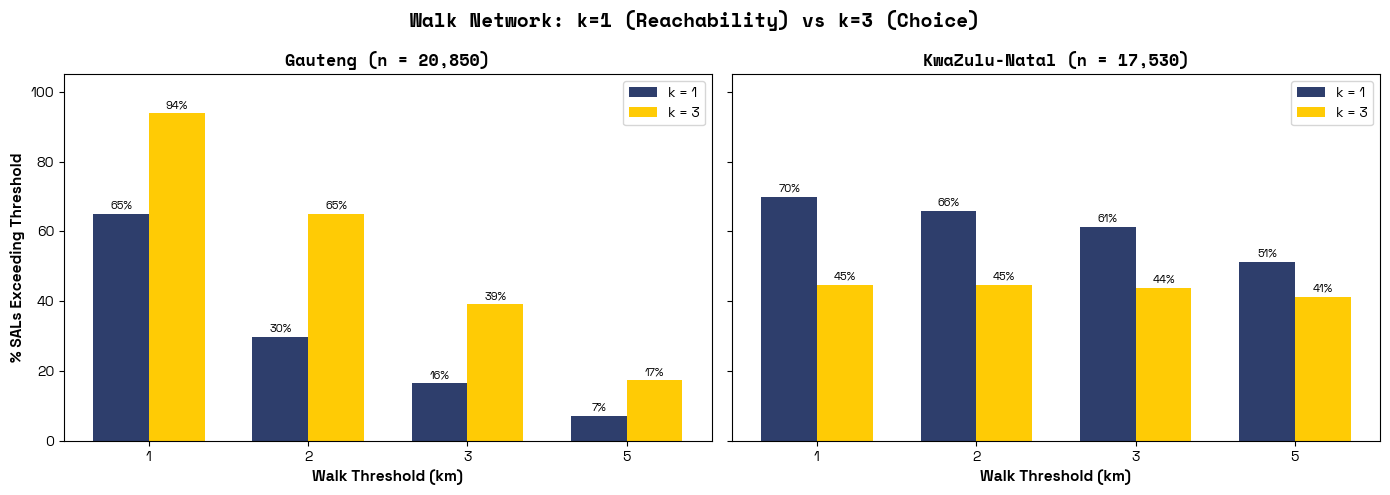

SAVED: images/threshold\walk_k1_vs_k3_bars.png


In [47]:
# Grouped bar chart: Walk exceedance by province, k=1 vs k=3.
fig, axes = plt.subplots(1, 2, figsize = (14, 5), sharey = True)

for ax_idx, province in enumerate(["Gauteng", "KwaZulu-Natal"]):
    prov_df = df[df["PR_NAME"] == province]
    n_prov = len(prov_df)

    k_vals = [1, 3]
    x = np.arange(len(WALK_THRESHOLDS_KM))
    width = 0.35
    colors = ["#2e3e6c", "#ffcb05"]

    for j, ki in enumerate(k_vals):
        pcts = []
        for t in WALK_THRESHOLDS_KM:
            flag = f"exceeds_walk_k{ki}_{t}km"
            if flag in prov_df.columns:
                pcts.append(prov_df[flag].mean() * 100)
            else:
                pcts.append(0)

        offset = (j - 0.5) * width
        bars = axes[ax_idx].bar(x + offset, pcts, width, label = f"k = {ki}", color = colors[j])

        # Add value labels.
        for bar, pct in zip(bars, pcts):
            if pct > 3:
                axes[ax_idx].text(
                    bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f"{pct:.0f}%", ha = "center", va = "bottom", fontsize = 8
                )

    axes[ax_idx].set_xlabel("Walk Threshold (km)", fontweight = "bold")
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels([f"{t}" for t in WALK_THRESHOLDS_KM])
    axes[ax_idx].set_title(f"{province} (n = {n_prov:,})", fontfamily = FONT_TITLE, fontsize = 12, fontweight = "bold")
    axes[ax_idx].legend()
    axes[ax_idx].set_ylim(0, 105)

axes[0].set_ylabel("% SALs Exceeding Threshold", fontweight = "bold")
fig.suptitle("Walk Network: k=1 (Reachability) vs k=3 (Choice)",
             fontfamily = FONT_TITLE, fontsize = 14, fontweight = "bold")
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "walk_k1_vs_k3_bars.png"), dpi = 150, bbox_inches = "tight")
plt.savefig(os.path.join(IMAGE_DIR, "walk_k1_vs_k3_bars_transparent.png"), dpi = 150, bbox_inches = "tight", transparent = True)
plt.show()
print(f"SAVED: {os.path.join(IMAGE_DIR, 'walk_k1_vs_k3_bars.png')}")

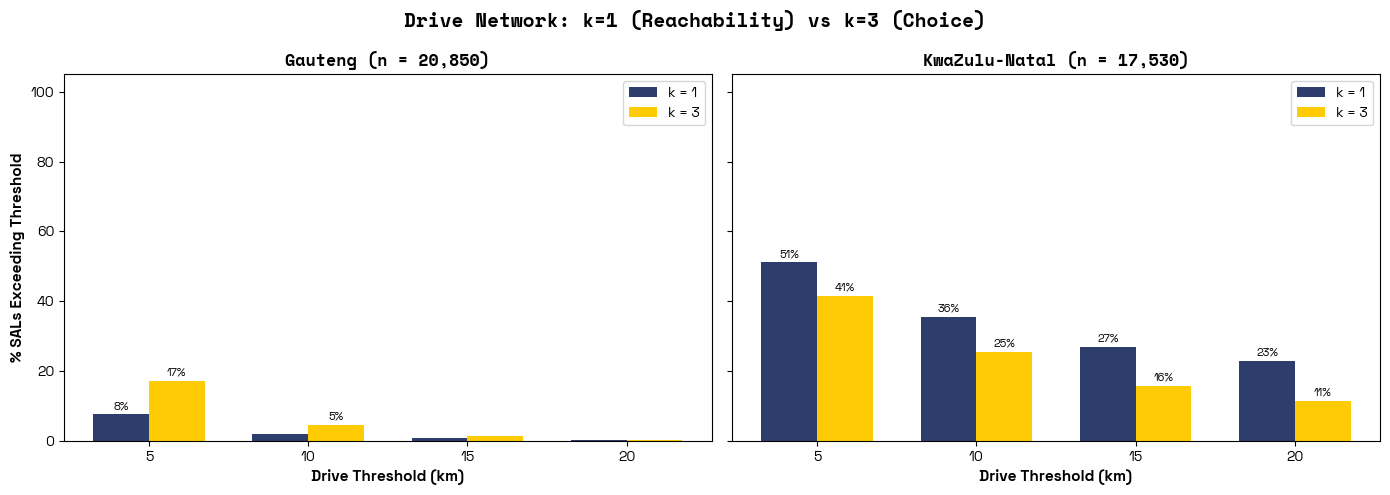

SAVED: images/threshold\drive_k1_vs_k3_bars.png


In [61]:
# Grouped bar chart: Drive exceedance by province, k=1 vs k=3.
fig, axes = plt.subplots(1, 2, figsize = (14, 5), sharey = True)

for ax_idx, province in enumerate(["Gauteng", "KwaZulu-Natal"]):
    prov_df = df[df["PR_NAME"] == province]
    n_prov = len(prov_df)

    k_vals = [1, 3]
    x = np.arange(len(DRIVE_THRESHOLDS_KM))
    width = 0.35
    colors = ["#2e3e6c", "#ffcb05"]

    for j, ki in enumerate(k_vals):
        pcts = []
        for t in DRIVE_THRESHOLDS_KM:
            flag = f"exceeds_drive_k{ki}_{t}km"
            if flag in prov_df.columns:
                pcts.append(prov_df[flag].mean() * 100)
            else:
                pcts.append(0)

        offset = (j - 0.5) * width
        bars = axes[ax_idx].bar(x + offset, pcts, width, label = f"k = {ki}", color = colors[j])

        for bar, pct in zip(bars, pcts):
            if pct > 3:
                axes[ax_idx].text(
                    bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f"{pct:.0f}%", ha = "center", va = "bottom", fontsize = 8
                )

    axes[ax_idx].set_xlabel("Drive Threshold (km)", fontweight = "bold")
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels([f"{t}" for t in DRIVE_THRESHOLDS_KM])
    axes[ax_idx].set_title(f"{province} (n = {n_prov:,})", fontfamily = FONT_TITLE, fontsize = 12, fontweight = "bold")
    axes[ax_idx].legend()
    axes[ax_idx].set_ylim(0, 105)

axes[0].set_ylabel("% SALs Exceeding Threshold", fontweight = "bold")
fig.suptitle("Drive Network: k=1 (Reachability) vs k=3 (Choice)",
             fontfamily = FONT_TITLE, fontsize = 14, fontweight = "bold")
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "drive_k1_vs_k3_bars.png"), dpi = 150, bbox_inches = "tight")
plt.savefig(os.path.join(IMAGE_DIR, "drive_k1_vs_k3_bars_transparent.png"), dpi = 150, bbox_inches = "tight", transparent = True)
plt.show()
print(f"SAVED: {os.path.join(IMAGE_DIR, 'drive_k1_vs_k3_bars.png')}")

## HEATMAPS: SETTLEMENT TYPE x THRESHOLD

Heatmaps for walk and drive networks showing exceedance rate by
province-settlement type combination. Separate panels for k=1 and k=3.

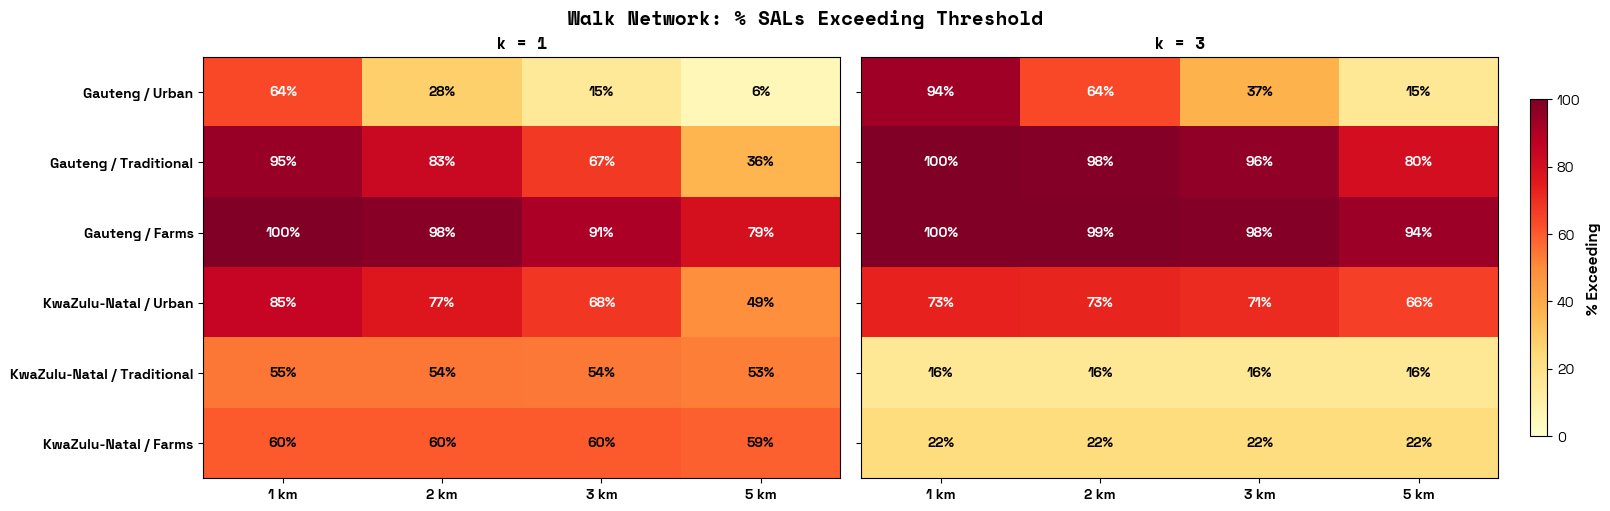

SAVED: images/threshold\heatmap_walk_k1_k3.png


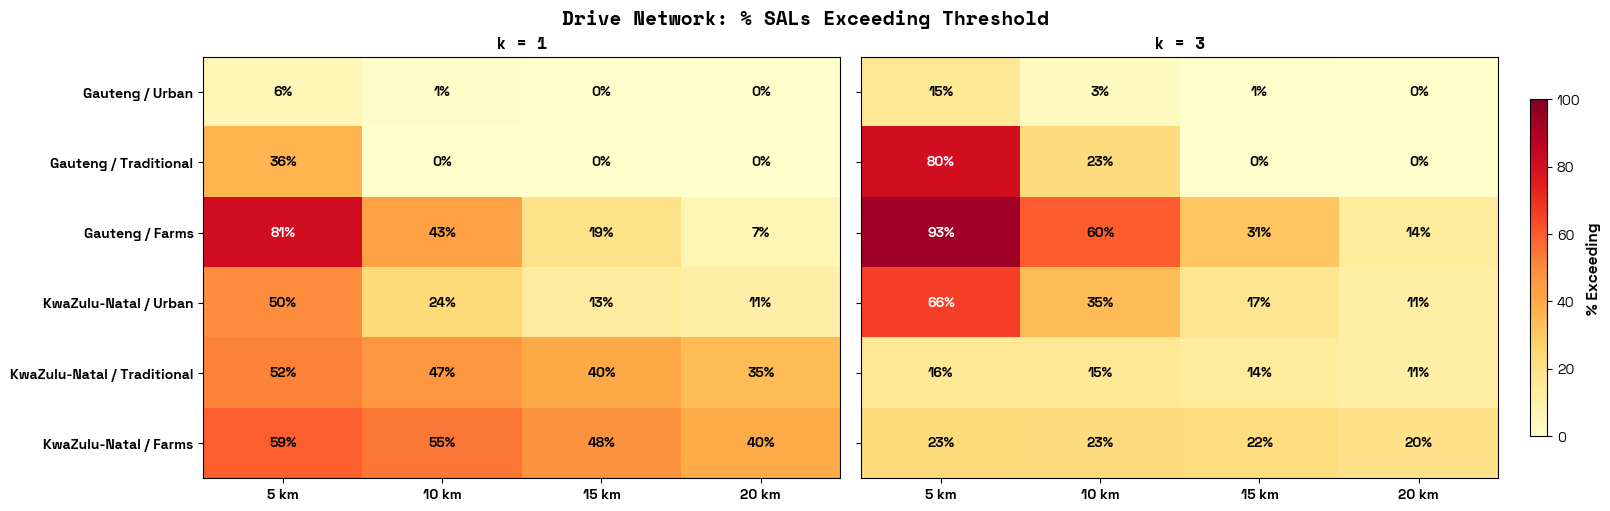

SAVED: images/threshold\heatmap_drive_k1_k3.png


In [52]:
# Build heatmap data for walk and drive, k=1 and k=3.
for mode, thresholds in [("walk", WALK_THRESHOLDS_KM), ("drive", DRIVE_THRESHOLDS_KM)]:
    fig, axes = plt.subplots(1, 2, figsize = (16, 5), sharey = True, constrained_layout = True)

    for ax_idx, ki in enumerate([1, 3]):
        ki_flags = flag_columns.get(ki, [])
        mode_flags = [f for f in ki_flags if f.startswith(f"exceeds_{mode}_k{ki}_")]
        if not mode_flags:
            continue

        # Build matrix: rows = province/settlement, columns = thresholds.
        heatmap_rows = []
        row_labels = []

        for province in ["Gauteng", "KwaZulu-Natal"]:
            prov_df = df[df["PR_NAME"] == province]
            for gtype in SETTLEMENT_ORDER:
                subset = prov_df[prov_df["EA_GTYPE"] == gtype]
                if len(subset) == 0:
                    continue
                row_labels.append(f"{province} / {gtype}")
                row_vals = []
                for fc in mode_flags:
                    row_vals.append(subset[fc].mean() * 100)
                heatmap_rows.append(row_vals)

        matrix = np.array(heatmap_rows)
        col_labels = [f"{t} km" for t in thresholds]

        im = axes[ax_idx].imshow(matrix, cmap = "YlOrRd", aspect = "auto", vmin = 0, vmax = 100)

        axes[ax_idx].set_xticks(range(len(col_labels)))
        axes[ax_idx].set_xticklabels(col_labels, fontweight = "bold")
        axes[ax_idx].set_yticks(range(len(row_labels)))
        axes[ax_idx].set_yticklabels(row_labels, fontweight = "bold")

        # Annotate cells.
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                val = matrix[i, j]
                color = "white" if val > 60 else "black"
                axes[ax_idx].text(j, i, f"{val:.0f}%", ha = "center", va = "center",
                                  color = color, fontsize = 10, fontweight = "bold")

        axes[ax_idx].set_title(f"k = {ki}", fontfamily = FONT_TITLE, fontsize = 12, fontweight = "bold")
        axes[ax_idx].set_facecolor("#fcffeb")

    fig.suptitle(f"{mode.capitalize()} Network: % SALs Exceeding Threshold",
                 fontfamily = FONT_TITLE, fontsize = 14, fontweight = "bold")
    cbar = fig.colorbar(im, ax = axes[-1], shrink = 0.8)
    cbar.set_label("% Exceeding", fontweight = "bold")

    save_path = os.path.join(IMAGE_DIR, f"heatmap_{mode}_k1_k3.png")

    plt.savefig(save_path, dpi = 150, bbox_inches = "tight")
    plt.savefig(f"{save_path}_transparent.png", dpi = 150, bbox_inches = "tight", transparent = True)
    plt.show()
    print(f"SAVED: {save_path}")

## POLICY SUMMARY TABLE

Formatted output for direct use in reports. Each row answers: at
threshold X, what proportion of SALs (and people) in each province
cannot reach their k-th nearest pharmacy?

In [35]:
# Build a clean summary table for report use.
summary_rows = []

for ki in K_LEVELS:
    ki_modes = dist_col_map.get(ki, {})

    for mode in ["walk", "drive"]:
        col = ki_modes.get(mode)
        if col is None:
            continue
        thresholds = threshold_config[mode]

        for t in thresholds:
            flag_col = f"exceeds_{mode}_k{ki}_{t}km"
            if flag_col not in df.columns:
                continue

            for province in ["Gauteng", "KwaZulu-Natal"]:
                prov_df = df[df["PR_NAME"] == province]
                n_total = len(prov_df)
                n_exceed = prov_df[flag_col].sum()
                pct_sal = n_exceed / n_total * 100

                pop_total = prov_df["sal2023_est"].sum()
                pop_exceed = prov_df.loc[prov_df[flag_col], "sal2023_est"].sum()
                pct_pop = pop_exceed / pop_total * 100 if pop_total > 0 else np.nan

                summary_rows.append({
                    "k": ki,
                    "Mode": mode.capitalize(),
                    "Threshold (km)": t,
                    "Province": province,
                    "SALs Total": n_total,
                    "SALs Exceeding": int(n_exceed),
                    "% SALs": round(pct_sal, 1),
                    "Pop Exceeding": int(pop_exceed),
                    "% Pop": round(pct_pop, 1)
                })

summary_df = pd.DataFrame(summary_rows)
print("POLICY SUMMARY TABLE")
print(summary_df.to_string(index = False))

POLICY SUMMARY TABLE
 k  Mode  Threshold (km)      Province  SALs Total  SALs Exceeding  % SALs  Pop Exceeding   % Pop
 1  Walk               1       Gauteng       20850           13535 64.9000       10005372 66.3000
 1  Walk               1 KwaZulu-Natal       17530           12267 70.0000        8825509 71.0000
 1  Walk               2       Gauteng       20850            6203 29.8000        4498747 29.8000
 1  Walk               2 KwaZulu-Natal       17530           11546 65.9000        8374235 67.4000
 1  Walk               3       Gauteng       20850            3434 16.5000        2385134 15.8000
 1  Walk               3 KwaZulu-Natal       17530           10738 61.3000        7791941 62.7000
 1  Walk               5       Gauteng       20850            1516  7.3000         838968  5.6000
 1  Walk               5 KwaZulu-Natal       17530            8980 51.2000        6471722 52.1000
 1 Drive               5       Gauteng       20850            1582  7.6000         904402  6.0000

## EXPORT RESULTS

In [36]:
# Export the analysis table with all threshold flags.
export_cols = ["EA_CODE", "PR_NAME", "EA_GTYPE", "EA_TYPE", "econ_status", "sal2023_est"]

# Add distance columns for all k levels.
for ki in K_LEVELS:
    for mode, col in dist_col_map.get(ki, {}).items():
        export_cols.append(col)

# Add all flag columns.
for ki in K_LEVELS:
    export_cols.extend(flag_columns.get(ki, []))

# Filter to columns that exist.
export_cols = [c for c in export_cols if c in df.columns]

# Export full analysis table.
full_export_path = "data/networks/sal_threshold_flags_k3.csv"
df[export_cols].to_csv(full_export_path, index = False)
print(f"EXPORTED: {full_export_path}")
print(f"Rows: {len(df)}, Columns: {len(export_cols)}")
print()

# Export the summary table.
summary_export_path = "data/networks/threshold_summary_k3.csv"
summary_df.to_csv(summary_export_path, index = False)
print(f"EXPORTED: {summary_export_path}")

EXPORTED: data/networks/sal_threshold_flags_k3.csv
Rows: 38380, Columns: 51

EXPORTED: data/networks/threshold_summary_k3.csv


## NOTES AND LIMITATIONS

- **k=1 vs k=3 interpretation:** k=1 exceedance answers "is there any
  pharmacy within reach?" while k=3 exceedance answers "are there three
  pharmacies within reach?" A SAL that passes k=1 but fails k=3 has
  fragile access, dependent on a single facility. The gap between k=1
  and k=3 exceedance rates is the "redundancy deficit."

- **Centroid assumption:** Distances are measured from geometric SAL
  centroids. For large or irregularly shaped SALs (common in rural KZN),
  some residents may be significantly farther from the nearest pharmacy
  than the centroid distance suggests.

- **OSM network completeness:** Missing roads in informal settlements
  and rural areas cause the algorithm to route around gaps, inflating
  computed distances. Walk distances in these areas may overestimate
  true pedestrian travel where informal footpaths exist.

- **Threshold selection:** The thresholds (e.g. 3 km walk, 10 km drive)
  are policy-relevant reference points but inherently arbitrary. An SAL
  at 3.1 km is classified differently from one at 2.9 km despite
  near-identical access. The multi-threshold approach mitigates this by
  showing the full exceedance curve rather than a single binary cut.

- **No transit mode:** The dominant transport mode for many South
  Africans (minibus taxi) is not captured in either the walk or drive
  network. A SAL classified as exceeding the walk threshold may be
  well-served by a taxi route that passes through a pharmacy cluster.